# Smart Energy Analytics

# Notebook 05: Model Optimization and Selection

---

## Project Description

This notebook focuses on optimizing and selecting the best deep learning model for household energy consumption forecasting.

Multiple forecasting experiments will be conducted using different LSTM architectures and time window sizes. Each model will be evaluated using standard regression metrics to identify the most accurate and reliable forecasting model.

The best-performing model will be selected for deployment in the final Smart Energy Analytics Dashboard.

---

## Objectives

- Compare multiple LSTM forecasting models.
- Evaluate different time window sizes.
- Measure model performance using MAE, RMSE, and R² Score.
- Select the best forecasting model.
- Save the final model for deployment.
- Prepare the project for the Business Dashboard.

---

## Notebook Workflow

1. Import Libraries
2. Load Processed Dataset
3. Define Experiments
4. Train Models
5. Evaluate Models
6. Compare Results
7. Select Best Model
8. Save Final Model
9. Conclusion

---

# Sections

 Section 1: Import Libraries

 Section 2: Load Processed Data

 Section 3: Define Experiments

 Section 4: Train Models

 Section 5: Evaluate Each Model

 Section 6: Compare Results

 Section 7: Select Best Model

 Section 8: Save Final Model

 Section 9: Conclusion

## Section 1: Import Libraries

In [50]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Section 2: Load Processed Dataset

In [51]:
data = data = pd.read_csv("daily_energy_data.csv")
print(data.head())
print()

print(data.shape)

     Datetime  Global_active_power  Global_reactive_power     Voltage  \
0  2006-12-16             3.053475               0.088187  236.243763   
1  2006-12-17             2.354486               0.156949  240.087028   
2  2006-12-18             1.530435               0.112356  241.231694   
3  2006-12-19             1.157079               0.104821  241.999313   
4  2006-12-20             1.545658               0.111804  242.308063   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0         13.082828        0.000000        1.378788       12.439394  
1          9.999028        1.411806        2.907639        9.264583  
2          6.421667        0.738194        1.820139        9.734722  
3          4.926389        0.582639        5.279167        4.303472  
4          6.467361        0.000000        1.838889        9.765972  

(1442, 8)


In [52]:
data.isnull().sum()

Datetime                 0
Global_active_power      9
Global_reactive_power    9
Voltage                  9
Global_intensity         9
Sub_metering_1           9
Sub_metering_2           9
Sub_metering_3           9
dtype: int64

In [53]:
data = data.dropna().reset_index(drop=True)

In [54]:
data.isnull().sum()

Datetime                 0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [55]:
data = data.drop(columns=["Datetime"])

# Section 3: Define Experiments

In [56]:
window_sizes  = [30,60,90]

results = []

## Section 4: Create Helper Functions

In [57]:
def create_sequences (data , window) :

    X = []
    y = []

    for i in range(window , len(data) ) :

        X.append(data[i - window :i])

        y.append(data[ i , 0])
    
    return np.array(X) , np.array(y)

# Build Improved LSTM

In [58]:
def build_model (input_shape) :

    model = Sequential()
    model.add (

        LSTM (
            128 ,
            return_sequences = True ,
            input_shape = input_shape 
        )
    )

    model.add(Dropout(0.2))
    model.add(LSTM(64))
    model.add(Dropout(0.2))
    model.add (Dense(32 , activation= "relu"))
    model.add(Dense(1))

    model.compile(

        optimizer=Adam(0.001),

        loss="mse",

        metrics=["mae"]
    )

    return model

# Section 5 : Training Loop

In [59]:
# ============================================
# Section 5 : Train Models
# ============================================

for window in window_sizes:

    print("=" * 50)
    print(f"Training Model (Window Size = {window})")
    print("=" * 50)

    # ----------------------------------------
    # Scale Data
    # ----------------------------------------
    
    scaler = MinMaxScaler()

    scaled_data = scaler.fit_transform(data)

    # ----------------------------------------
    # Create Sequences
    # ----------------------------------------

    X, y = create_sequences(scaled_data, window)

    # ----------------------------------------
    # Train/Test Split
    # ----------------------------------------

    split = int(len(X) * 0.8)

    X_train = X[:split]
    X_test = X[split:]

    y_train = y[:split]
    y_test = y[split:]

    # ----------------------------------------
    # Build Model
    # ----------------------------------------

    model = build_model(
        (X_train.shape[1], X_train.shape[2])
    )

    # ----------------------------------------
    # Early Stopping
    # ----------------------------------------

    early_stop = EarlyStopping(

        monitor="val_loss",

        patience=5,

        restore_best_weights=True

    )

    # ----------------------------------------
    # Training Time
    # ----------------------------------------

    start = time.time()

    history = model.fit(

        X_train,
        y_train,

        validation_data=(X_test, y_test),

        epochs=30,

        batch_size=32,

        callbacks=[early_stop],

        verbose=1

    )

    end = time.time()

    training_time = end - start

    # ----------------------------------------
    # Prediction
    # ----------------------------------------

    predictions = model.predict(X_test)

    # ----------------------------------------
    # Evaluation
    # ----------------------------------------

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_test, predictions)
    )

    r2 = r2_score(y_test, predictions)

    # ----------------------------------------
    # Save Results
    # ----------------------------------------

    results.append({

        "Window": window,

        "MAE": mae,

        "RMSE": rmse,

        "R2": r2,

        "Training Time": training_time

    })

    print()

    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    print()

Training Model (Window Size = 30)
Epoch 1/30


c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0172 - mae: 0.0986 - val_loss: 0.0089 - val_mae: 0.0752
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0114 - mae: 0.0811 - val_loss: 0.0099 - val_mae: 0.0804
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0118 - mae: 0.0803 - val_loss: 0.0074 - val_mae: 0.0673
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0114 - mae: 0.0799 - val_loss: 0.0062 - val_mae: 0.0590
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0110 - mae: 0.0779 - val_loss: 0.0067 - val_mae: 0.0634
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0105 - mae: 0.0775 - val_loss: 0.0082 - val_mae: 0.0719
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0109 - mae: 0.0782 - val_loss: 0.0060 - val_mae: 0.0587
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0116 - mae: 0.0807 - val_loss: 0.0077 - val_mae: 0.0692
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0113 - mae: 0.

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.0189 - mae: 0.1053 - val_loss: 0.0063 - val_mae: 0.0607
Epoch 2/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0110 - mae: 0.0784 - val_loss: 0.0066 - val_mae: 0.0625
Epoch 3/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0107 - mae: 0.0790 - val_loss: 0.0061 - val_mae: 0.0594
Epoch 4/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0104 - mae: 0.0769 - val_loss: 0.0061 - val_mae: 0.0590
Epoch 5/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.0106 - mae: 0.0786 - val_loss: 0.0061 - val_mae: 0.0587
Epoch 6/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0105 - mae: 0.0774 - val_loss: 0.0060 - val_mae: 0.0580
Epoch 7/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0102 - mae: 0.0761 - val_loss: 0.0061 - val_mae: 0.0589
Epoch 8/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0099 - mae: 0.0757 - val_loss: 0.0062 - val_mae: 0.0582
Epoch 9/30
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0103 - mae: 0.

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0188 - mae: 0.1051 - val_loss: 0.0070 - val_mae: 0.0649
Epoch 2/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0112 - mae: 0.0824 - val_loss: 0.0087 - val_mae: 0.0730
Epoch 3/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0108 - mae: 0.0797 - val_loss: 0.0067 - val_mae: 0.0622
Epoch 4/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0101 - mae: 0.0770 - val_loss: 0.0071 - val_mae: 0.0639
Epoch 5/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0097 - mae: 0.0741 - val_loss: 0.0062 - val_mae: 0.0593
Epoch 6/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0098 - mae: 0.0751 - val_loss: 0.0065 - val_mae: 0.0611
Epoch 7/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0095 - mae: 0.0741 - val_loss: 0.0061 - val_mae: 0.0586
Epoch 8/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0092 - mae: 0.0728 - val_loss: 0.0060 - val_mae: 0.0582
Epoch 9/30
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0092 - mae: 0.


# Section 6 : Compare Results


In [60]:
# ============================================
# Section 6 : Compare Results
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

print(results_df)

   Window       MAE      RMSE        R2  Training Time
0      90  0.056123  0.075364  0.394611      52.939203
1      60  0.056032  0.075523  0.407772      35.447279
2      30  0.056038  0.075665  0.413631      14.456512


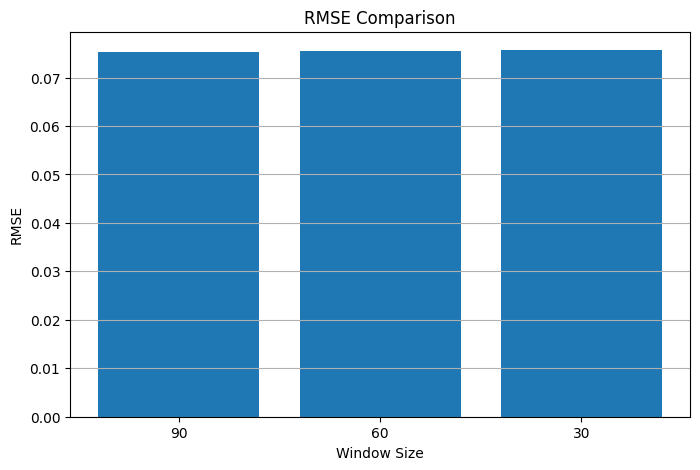

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Window"].astype(str),
    results_df["RMSE"]
)

plt.title("RMSE Comparison")

plt.xlabel("Window Size")

plt.ylabel("RMSE")

plt.grid(axis="y")

plt.show()

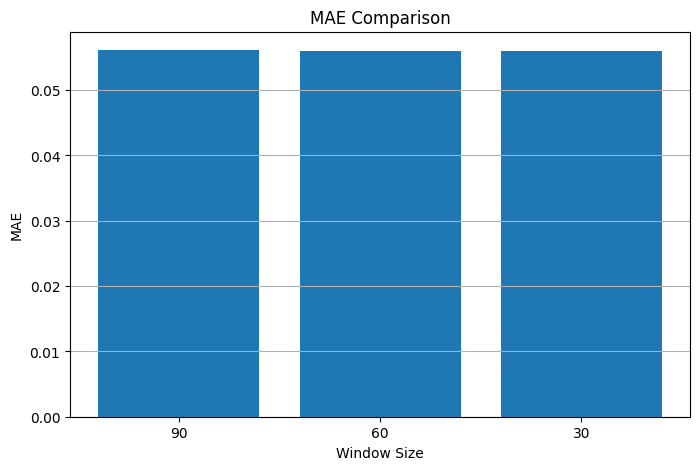

In [62]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Window"].astype(str),
    results_df["MAE"]
)

plt.title("MAE Comparison")

plt.xlabel("Window Size")

plt.ylabel("MAE")

plt.grid(axis="y")

plt.show()

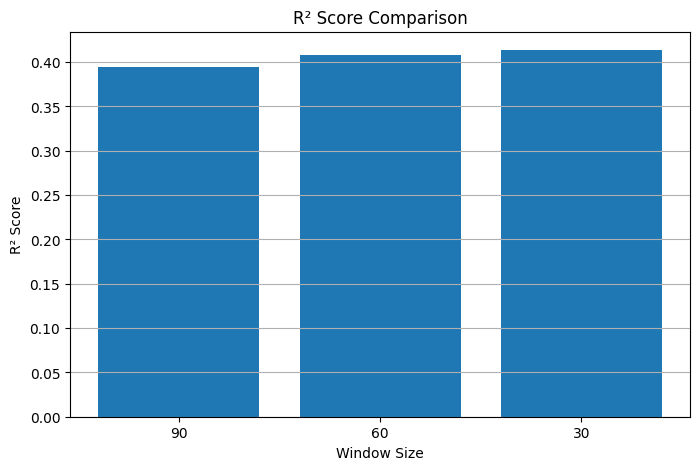

In [63]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Window"].astype(str),
    results_df["R2"]
)

plt.title("R² Score Comparison")

plt.xlabel("Window Size")

plt.ylabel("R² Score")

plt.grid(axis="y")

plt.show()